In [12]:
import pandas as pd 

df = pd.read_csv('insurance_charges.csv')
df.head()


,age,gender,bmi,charges
0,54,0,24.035,10422.91665
1,49,1,29.925,8988.15875
2,48,0,30.780,10141.13620
3,45,0,22.895,21098.55405
4,48,1,32.300,10043.24900


In [3]:
df.shape

(500, 4)

In [4]:
X = df[['age', "gender", "bmi"]]
y = df[['charges']]

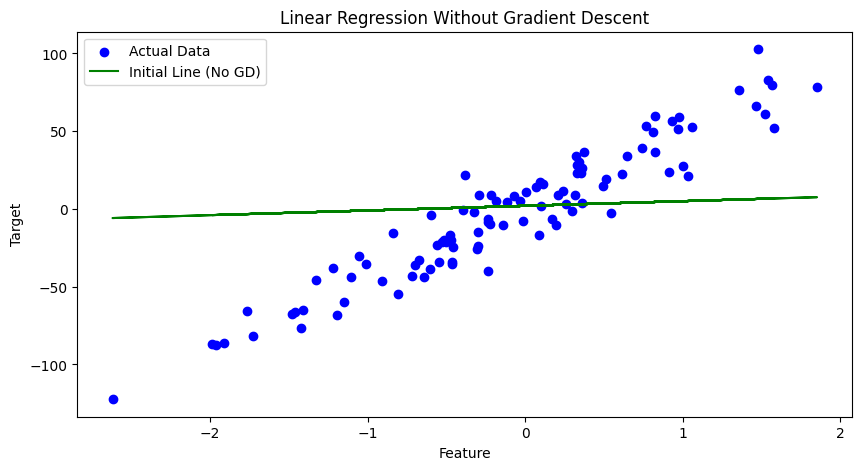

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=100, n_features=1, noise=15, random_state=42)
y = y.reshape(-1, 1)
m = X.shape[0]

X_b = np.c_[np.ones((m, 1)), X]

theta = np.array([[2.0], [3.0]])

plt.figure(figsize=(10, 5))
plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X, X_b.dot(theta), color="green", label="Initial Line (No GD)")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Linear Regression Without Gradient Descent")
plt.legend()
plt.show()

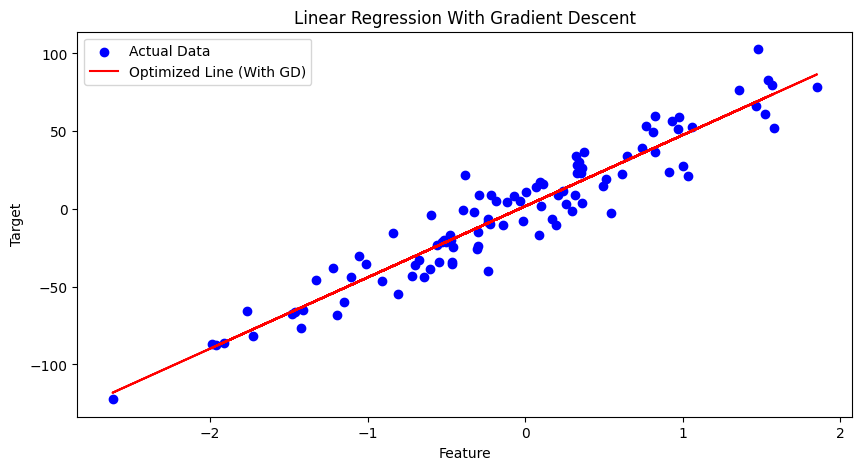

In [10]:
learning_rate = 0.2
n_iterations = 100

for _ in range(n_iterations):

    y_pred = X_b.dot(theta)

    gradients = (2 / m) * X_b.T.dot(y_pred - y)

    theta -= learning_rate * gradients

plt.figure(figsize=(10, 5))
plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X, X_b.dot(theta), color="red", label="Optimized Line (With GD)")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Linear Regression With Gradient Descent")
plt.legend()
plt.show()

In [13]:
df[df['age'] == 31]

,age,gender,bmi,charges
5,31,0,38.390,4463.20510
21,31,1,38.095,58571.07448
44,31,1,25.800,4934.70500
188,31,1,32.775,5327.40025
205,31,0,28.595,4243.59005
248,31,1,29.100,3761.29200
268,31,0,39.490,3875.73410
394,31,0,25.935,4239.89265
411,31,1,21.755,4134.08245
441,31,0,28.500,6799.45800


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("insurance_charges.csv")
# print("Dataset shape:", df.shape)
# print(df.head())

X = df[["age", "gender", "bmi"]].to_numpy(dtype=float)
y = df["charges"].to_numpy(dtype=float)

n_samples, n_features = X.shape

X_mean, X_std = X.mean(axis=0), X.std(axis=0)
y_mean, y_std = y.mean(), y.std()

X_scaled = (X - X_mean) / X_std
y_scaled = (y - y_mean) / y_std

X_design = np.hstack([np.ones((n_samples, 1)), X_scaled])  

def gradient_descent(X, y, alpha=0.01, n_iters=1000, w_init=None):
    n, d = X.shape
    w = np.zeros(d) if w_init is None else w_init.copy()
    loss_history = []
    for i in range(n_iters):
        y_pred = X @ w
        error = y_pred - y
        loss = (1 / (2 * n)) * np.sum(error ** 2)  
        loss_history.append(loss)
        grad = (1 / n) * (X.T @ error)
        w = w - alpha * grad
    return w, loss_history

alpha = 0.01
n_iters = 1000
w_final, loss_history = gradient_descent(X_design, y_scaled, alpha=alpha, n_iters=n_iters)

print("\n=== Results with alpha = 0.01 ===")
print("Final weight vector:")
print(w_final)
print(f"Initial loss: {loss_history[0]:.6f}")
print(f"Final loss: {loss_history[-1]:.6f}")

plt.figure(figsize=(7, 5))
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Loss (MSE)")
plt.title(f"Training Loss History (alpha = {alpha})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("loss_history_alpha_0.01.png", dpi=150)
plt.close()

learning_rates = [0.001, 0.01, 0.1, 0.15, 0.5, 1.0]

results = {}

plt.figure(figsize=(8, 6))

for lr in learning_rates:

    w_lr, hist_lr = gradient_descent(X_design, y_scaled, alpha=lr, n_iters=n_iters)

    results[lr] = (w_lr, hist_lr)

    print(f"alpha={lr:<6} " f"final_loss={hist_lr[-1]}")

    hist_plot = np.nan_to_num(
        np.array(hist_lr),
        nan=1e6,
        posinf=1e6,
        neginf=1e6
    )

    hist_plot = np.clip(hist_plot,1e-6,1e6)

    plt.plot(hist_plot, label=f"alpha={lr}")

plt.xlabel("Iteration")
plt.ylabel("Loss (MSE)")
plt.title("Training Loss for Different Learning Rates")
plt.yscale("log")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("loss_history_multi_lr.png", dpi=150)
plt.close()

new_data = pd.DataFrame({
    "age":    [31, 43, 28, 50],
    "gender": [0, 1, 1, 0],
    "bmi":    [22, 19, 33, 28],
})

new_X_scaled = (new_data[["age", "gender", "bmi"]].to_numpy(dtype=float) - X_mean) / X_std
new_X_design = np.hstack([np.ones((new_X_scaled.shape[0], 1)), new_X_scaled])

pred_scaled = new_X_design @ w_final
pred_charges = pred_scaled * y_std + y_mean 

new_data["predicted_charges"] = pred_charges
print("\n=== Predictions ===")
print(new_data)

new_data.to_csv("predictions.csv", index=False)


=== Results with alpha = 0.01 ===
Final weight vector:
[-1.08091314e-16  2.25999624e-01 -9.84748600e-02  1.97325361e-01]
Initial loss: 0.500000
Final loss: 0.444704
alpha=0.001  final_loss=0.4507282900075194
alpha=0.01   final_loss=0.44470439521049515
alpha=0.1    final_loss=0.44470439518957444
alpha=0.15   final_loss=0.44470439518957444
alpha=0.5    final_loss=0.4447043951895745
alpha=1.0    final_loss=0.4447043951895745

=== Predictions ===
   age  gender  bmi  predicted_charges
0   31       0   22        9407.691004
1   43       1   19        8188.652728
2   28       1   33       10829.298162
3   50       0   28       15517.117954
